# Environment Setup (Force Java 11 + Spark)

In [1]:
import os

# Hadoop (must be set BEFORE Spark starts)
os.environ["HADOOP_HOME"] = r"C:\hadoop-3.0.0"
os.environ["hadoop.home.dir"] = r"C:\hadoop-3.0.0"
os.environ["PATH"] = os.environ["HADOOP_HOME"] + r"\bin;" + os.environ["PATH"]

In [2]:
import os

os.environ["JAVA_HOME"] = r"C:\Program Files\Eclipse Adoptium\jdk-11.0.30.7-hotspot"
os.environ["SPARK_HOME"] = r"C:\Users\HP\Downloads\spark-3.5.8-bin-hadoop3\spark-3.5.8-bin-hadoop3"
os.environ["PATH"] = os.environ["SPARK_HOME"] + r"\bin;" + os.environ["JAVA_HOME"] + r"\bin;" + os.environ["PATH"]

In [3]:
from pyspark.sql import functions as F
from pyspark.sql.types import *
from pyspark.storagelevel import StorageLevel

from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    VectorAssembler, StandardScaler, StringIndexer
)
from pyspark.ml.classification import (
    LogisticRegression, RandomForestClassifier, GBTClassifier
)
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

import time
import numpy as np

## Initialize Spark Session (Stable Configuration)

In [4]:
import findspark
findspark.init()

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("HIGGS-BigData-Classification") \
    .config("spark.sql.shuffle.partitions", "200") \
    .config("spark.executor.memory", "4g") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

spark

# Data Ingestion Strategy 

In [5]:
from pyspark.sql import functions as F

df = (
    spark.read
    .option("header", "true")
    .option("sep", ",")          
    .option("inferSchema", "true")
    .csv("E:\Datasets\HIGGS_small.csv")
)

In [6]:
df.printSchema()

root
 |-- label: double (nullable = true)
 |-- f1: double (nullable = true)
 |-- f2: double (nullable = true)
 |-- f3: double (nullable = true)
 |-- f4: double (nullable = true)
 |-- f5: double (nullable = true)
 |-- f6: double (nullable = true)
 |-- f7: double (nullable = true)
 |-- f8: double (nullable = true)
 |-- f9: double (nullable = true)
 |-- f10: double (nullable = true)
 |-- f11: double (nullable = true)
 |-- f12: double (nullable = true)
 |-- f13: double (nullable = true)
 |-- f14: double (nullable = true)
 |-- f15: double (nullable = true)
 |-- f16: double (nullable = true)
 |-- f17: double (nullable = true)
 |-- f18: double (nullable = true)
 |-- f19: double (nullable = true)
 |-- f20: double (nullable = true)
 |-- f21: double (nullable = true)
 |-- f22: double (nullable = true)
 |-- f23: double (nullable = true)
 |-- f24: double (nullable = true)
 |-- f25: double (nullable = true)
 |-- f26: double (nullable = true)
 |-- f27: double (nullable = true)
 |-- f28: double (null

In [7]:
df.select(
    F.count("*").alias("rows"),
    F.count("label").alias("non_null_labels"),
    F.count(F.when(F.col("label").isNull(), 1)).alias("null_labels")
).show()

+----+---------------+-----------+
|rows|non_null_labels|null_labels|
+----+---------------+-----------+
|3500|           3500|          0|
+----+---------------+-----------+



# Data Validation Checks

In [8]:
from pyspark.ml.feature import Imputer

feature_cols = [f"f{i}" for i in range(1, 29)]

imputer = Imputer(
    inputCols=feature_cols,
    outputCols=feature_cols,
    strategy="median"
)

df = imputer.fit(df).transform(df)

In [9]:
df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in df.columns
]).show()

+-----+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+
|label| f1| f2| f3| f4| f5| f6| f7| f8| f9|f10|f11|f12|f13|f14|f15|f16|f17|f18|f19|f20|f21|f22|f23|f24|f25|f26|f27|f28|
+-----+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+
|    0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|
+-----+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+



In [10]:
from pyspark.storagelevel import StorageLevel

df.persist(StorageLevel.MEMORY_AND_DISK)
df.count()

3500

In [11]:
pdf = df.sample(fraction=0.2, seed=42).toPandas()

pdf.shape
pdf["label"].value_counts()

label
1.0    381
0.0    339
Name: count, dtype: int64

# EDA

## EDA 1: Class Imbalance (Bar Plot)

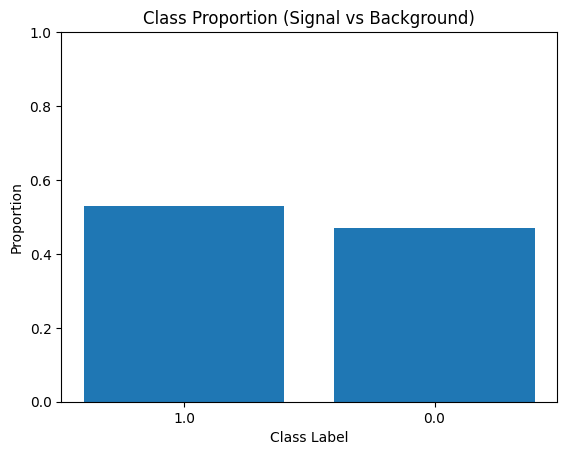

In [12]:
import matplotlib.pyplot as plt

counts = pdf["label"].value_counts(normalize=True)

plt.bar(counts.index.astype(str), counts.values)
plt.title("Class Proportion (Signal vs Background)")
plt.xlabel("Class Label")
plt.ylabel("Proportion")
plt.ylim(0, 1)
plt.show()

## EDA 2 – Feature Summary Statistics

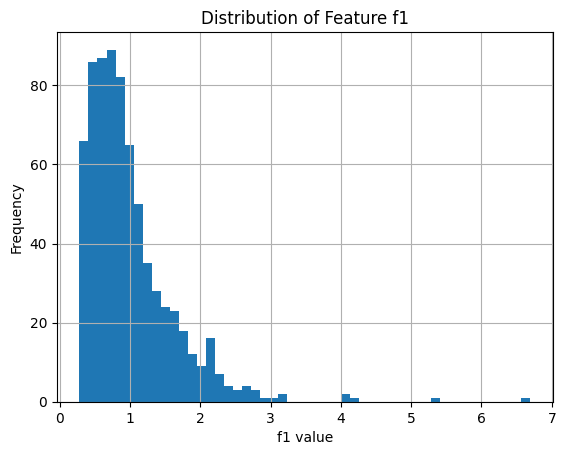

In [13]:
pdf["f1"].hist(bins=50)
plt.title("Distribution of Feature f1")
plt.xlabel("f1 value")
plt.ylabel("Frequency")
plt.show()

## EDA 3: Feature vs Label (Boxplot)

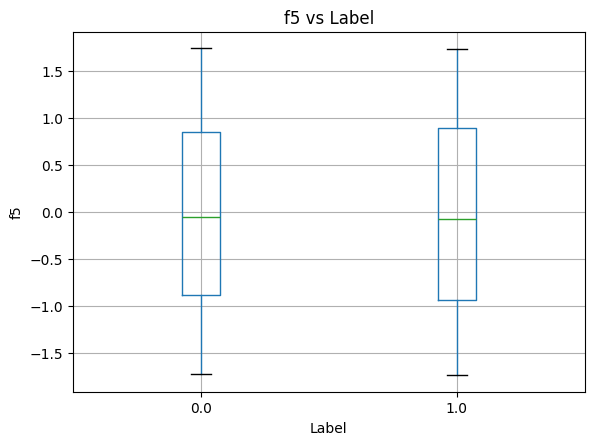

In [14]:
pdf.boxplot(column="f5", by="label")
plt.title("f5 vs Label")
plt.suptitle("")
plt.xlabel("Label")
plt.ylabel("f5")
plt.show()

## EDA 4: Correlation Heatmap (Key Features)

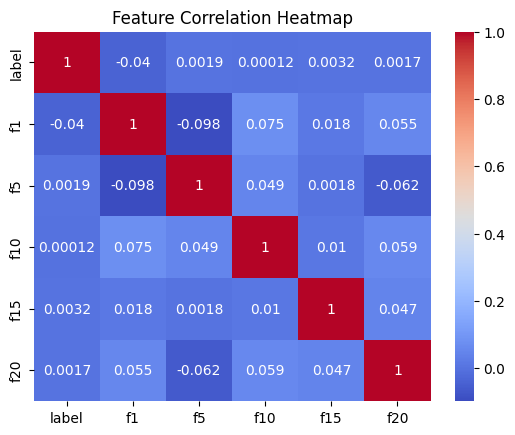

In [15]:
import seaborn as sns

corr_features = ["label", "f1", "f5", "f10", "f15", "f20"]
corr = pdf[corr_features].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

## EDA 5: Feature Sparsity

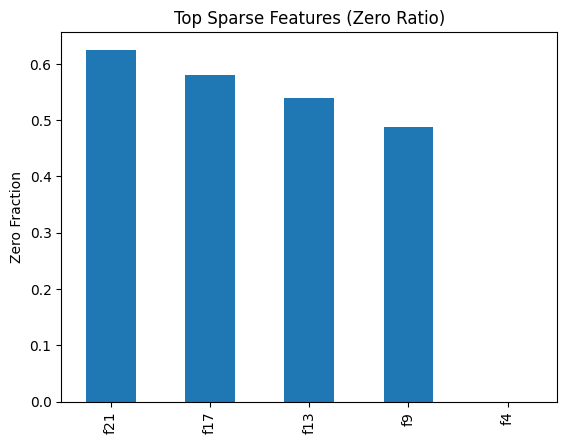

In [16]:
zero_ratio = (pdf[feature_cols] == 0).mean().sort_values(ascending=False)[:5]
zero_ratio.plot(kind="bar")
plt.title("Top Sparse Features (Zero Ratio)")
plt.ylabel("Zero Fraction")
plt.show()